In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-support-ticket-dataset/customer_support_tickets.csv


**Customer Support Ticket EDA — Operational & Experience Insights**

This analysis focuses on understanding ticket lifecycle behavior, support workload patterns, and customer experience signals.

Instead of treating missing values and status fields as raw columns, the goal is to interpret them as process indicators that explain how the support system operates.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
df = pd.read_csv('/kaggle/input/customer-support-ticket-dataset/customer_support_tickets.csv')

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


**What this dataset represents**

* tickets = workflow events
* status = lifecycle stage
* priority = urgency signal
* channel = customer entry point
* resolution + satisfaction = outcome quality

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [5]:
print(df.shape) #shape of data represents number of rows and columns

(8469, 17)


In [6]:
df.isnull().sum() #columns that have null values - helps to decide whether to drop such columns

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [7]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns 
text_columns = df.select_dtypes(include=['object']).columns
#this would help to understand which columns would need encoding

print(f'numerical_columns: {numerical_columns}')
print(f'text_columns: {text_columns}')


numerical_columns: Index(['Ticket ID', 'Customer Age', 'Customer Satisfaction Rating'], dtype='object')
text_columns: Index(['Customer Name', 'Customer Email', 'Customer Gender',
       'Product Purchased', 'Date of Purchase', 'Ticket Type',
       'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution',
       'Ticket Priority', 'Ticket Channel', 'First Response Time',
       'Time to Resolution'],
      dtype='object')


In [8]:
print(f'Total Columns: {df.shape[1]}')
print(f'Numeric Columns: {len(numerical_columns)}')
print(f'Text Columns: {len(text_columns)}')

Total Columns: 17
Numeric Columns: 3
Text Columns: 14


In [9]:
missing_percentage = (df.isnull().mean() * 100).round(2) # will help to decide whether to drop columns

missing_df = pd.DataFrame({"Missing Count":df.isnull().sum(),
                           "Missing %":missing_percentage})

missing_df = missing_df[missing_df['Missing Count']>0]
print(missing_df)

                              Missing Count  Missing %
Resolution                             5700      67.30
First Response Time                    2819      33.29
Time to Resolution                     5700      67.30
Customer Satisfaction Rating           5700      67.30


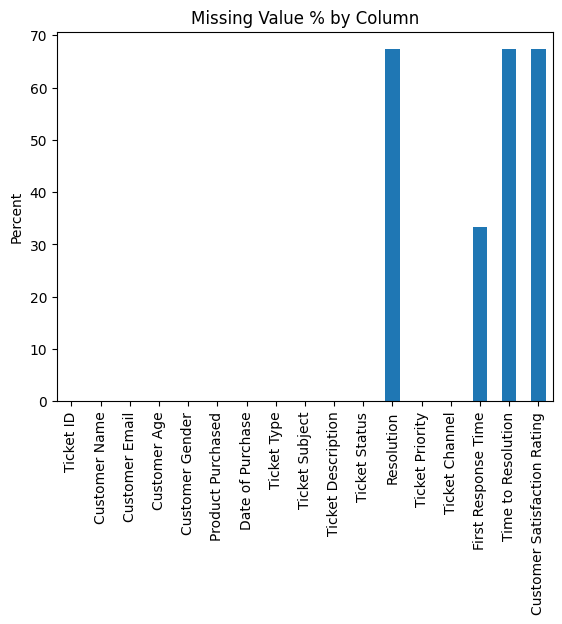

In [10]:
missing_percentage.plot(kind = 'bar')
plt.title("Missing Value % by Column")
plt.ylabel("Percent")
plt.show()

In [11]:
df['Ticket Status'].value_counts() #spread of ticket across different status

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

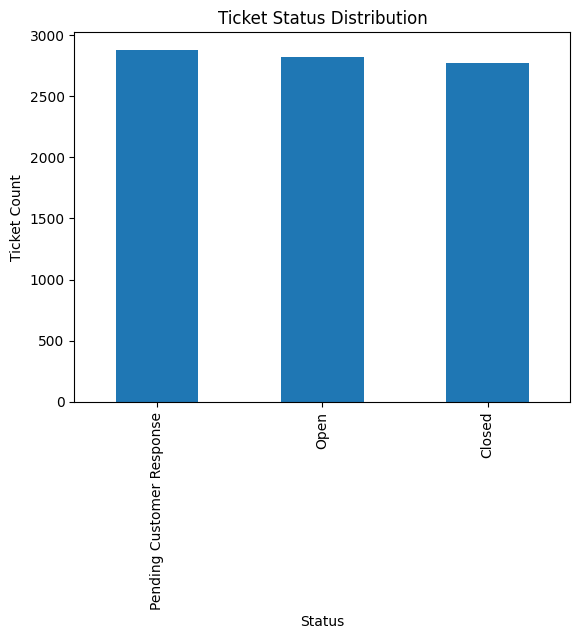

In [12]:
df["Ticket Status"].value_counts().plot(kind="bar")
plt.title("Ticket Status Distribution")
plt.xlabel("Status")
plt.ylabel("Ticket Count")
plt.show()


**Insight (Lifecycle Interpretation)**

Closed → completed workflow

Open → active backlog

Pending Customer Response → waiting state

Status values reflect queue movement, not static labels

In [13]:
df['Ticket Priority'].value_counts() #what priority most of the tickets being addressed are

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

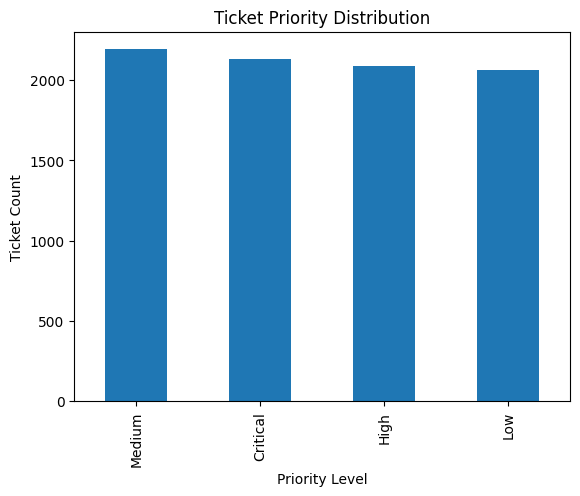

In [14]:
df['Ticket Priority'].value_counts().plot(kind='bar')
plt.title('Ticket Priority Distribution')
plt.xlabel('Priority Level')
plt.ylabel('Ticket Count')
plt.show()

**🔍 Insight (Operational Stress Signal)**

Higher concentration of High / Urgent tickets
→ indicates workload pressure areas

Low-priority volume shows routine traffic

In [15]:
df['Ticket Channel'].value_counts() #Differnt ticket channels available

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

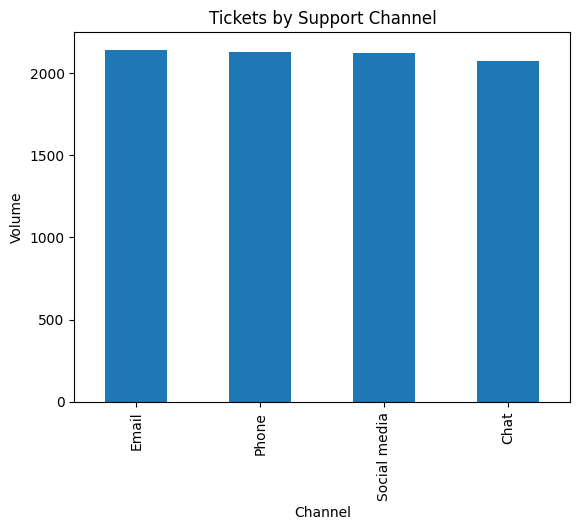

In [16]:
df['Ticket Channel'].value_counts().plot(kind='bar')
plt.title('Tickets by Support Channel')
plt.xlabel('Channel')
plt.ylabel('Volume')
plt.show()

**🔍 Insight (Customer Behavior & Routing)**

Customers prefer Email for first-contact

This affects staffing and routing decisions

In [17]:
df['Customer Satisfaction Rating'].value_counts(dropna = False) #missing values means unrated / unresolved, not a data quality problem, customers rate only after resolution

Customer Satisfaction Rating
NaN    5700
3.0     580
1.0     553
2.0     549
5.0     544
4.0     543
Name: count, dtype: int64

In [18]:
# Satisfaction vs Ticket Priority
priority_satisfaction = df.groupby('Ticket Priority')['Customer Satisfaction Rating'].mean() #higher stress cases → lower perceived experience
print(priority_satisfaction)

Ticket Priority
Critical    2.958678
High        2.982979
Low         3.052795
Medium      2.976945
Name: Customer Satisfaction Rating, dtype: float64


In [19]:
#Satisfaction vs Channel
channel_satisfaction = df.groupby('Ticket Channel')['Customer Satisfaction Rating'].mean() #which support channel has higher satisfacted rating
print(channel_satisfaction)

Ticket Channel
Chat            3.083086
Email           2.963889
Phone           2.952243
Social media    2.969298
Name: Customer Satisfaction Rating, dtype: float64


**🔍 Insight (Experience Signal)**

Critical tickets show lower satisfaction due to urgency + delay risk

Faster channels correlate with better experience

In [20]:
# Unresolved Tickets vs Status
df['is_resolved'] = df['Time to Resolution'].notnull() # True = ticket has resolution timestamp (Closed), False = unresolved / still in workflow
df.groupby('Ticket Status')['is_resolved'].mean()

Ticket Status
Closed                       1.0
Open                         0.0
Pending Customer Response    0.0
Name: is_resolved, dtype: float64

**Key Learnings (AI Architecture Perspective)**

EDA helped interpret workflow behavior, not just visualize data

Missing timestamps acted as lifecycle indicators

Priority and channel patterns revealed operational stress points

Satisfaction trends connected to resolution dynamics

**Possible Extensions**

SLA breach risk prediction

Resolution-time forecasting

Ticket triage automation

Channel-wise demand planning

**What This Enables Next (From an AI & Decision Engineering Perspective)**
This EDA does not stop at visualization — it establishes foundation for:

**Ticket Triage Recommendation**
Identify which tickets should be escalated earlier
Prioritize based on urgency + impact signals

**Channel-wise Demand Planning**
Understand where customers prefer to raise tickets
Optimize support routing & workforce allocation

**Customer Experience Health Monitoring**
Connect satisfaction trends to:
delays
channel choice
case priority
Supports experience-driven decision making

**Process Health Visibility**
Missing timestamps interpreted as lifecycle states
Helps distinguish:
unresolved
in-progress
stalled workflow cases

🔍This transforms EDA from **data exploration → operational intelligence**.

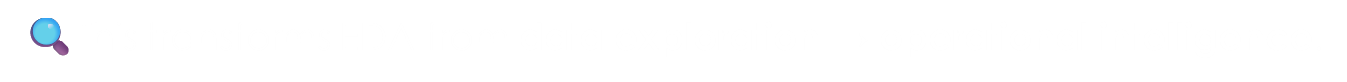
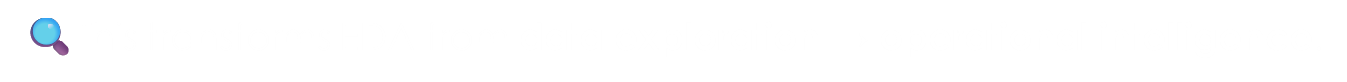
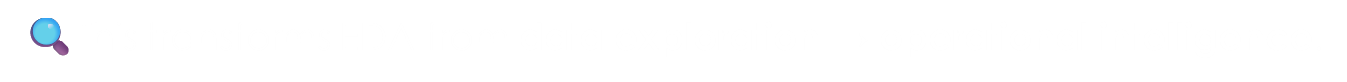
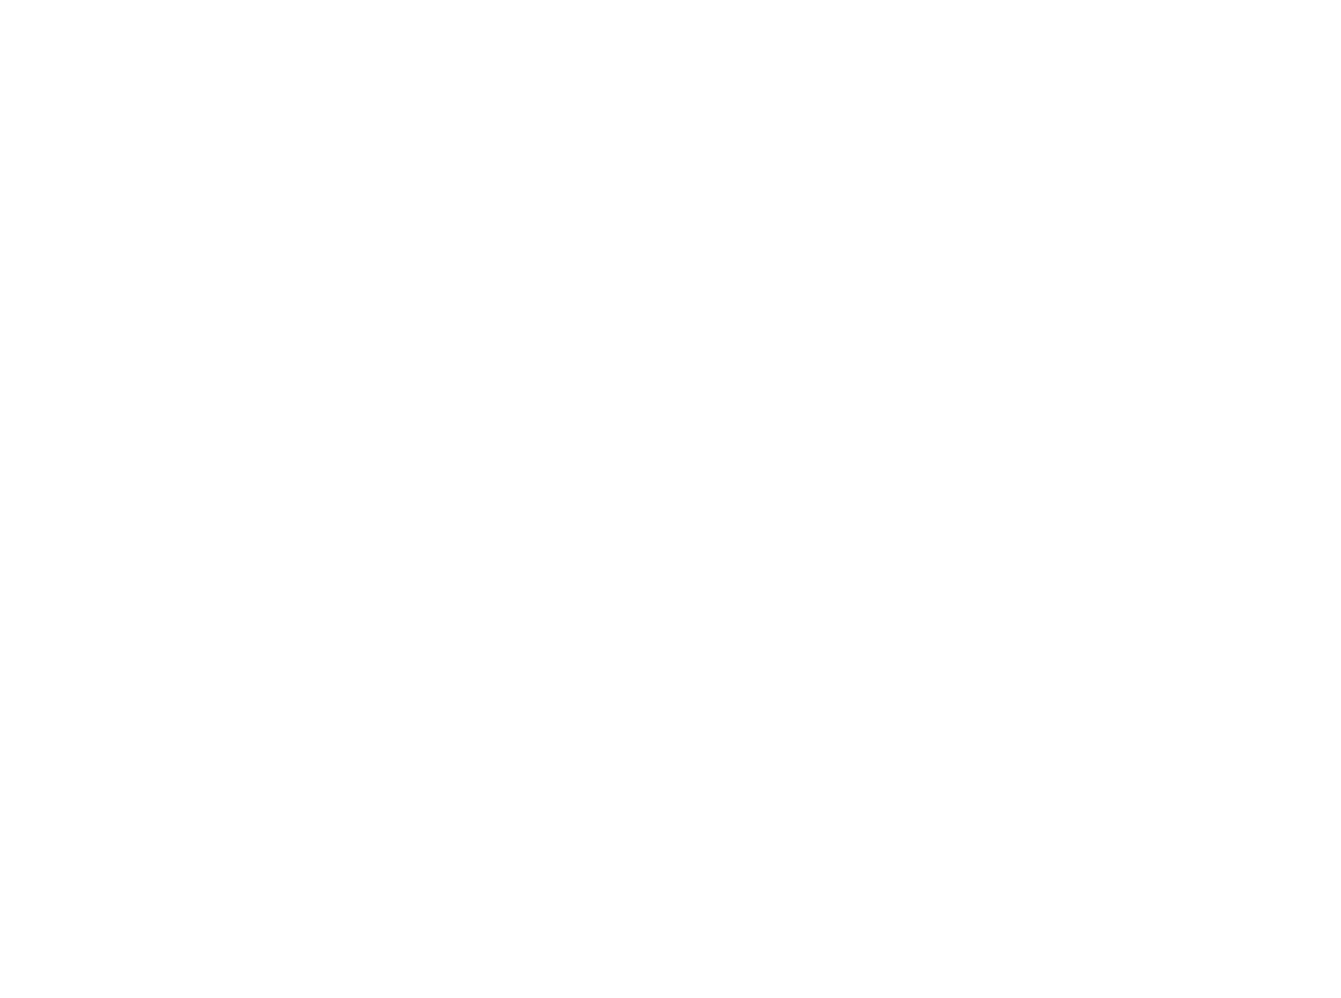
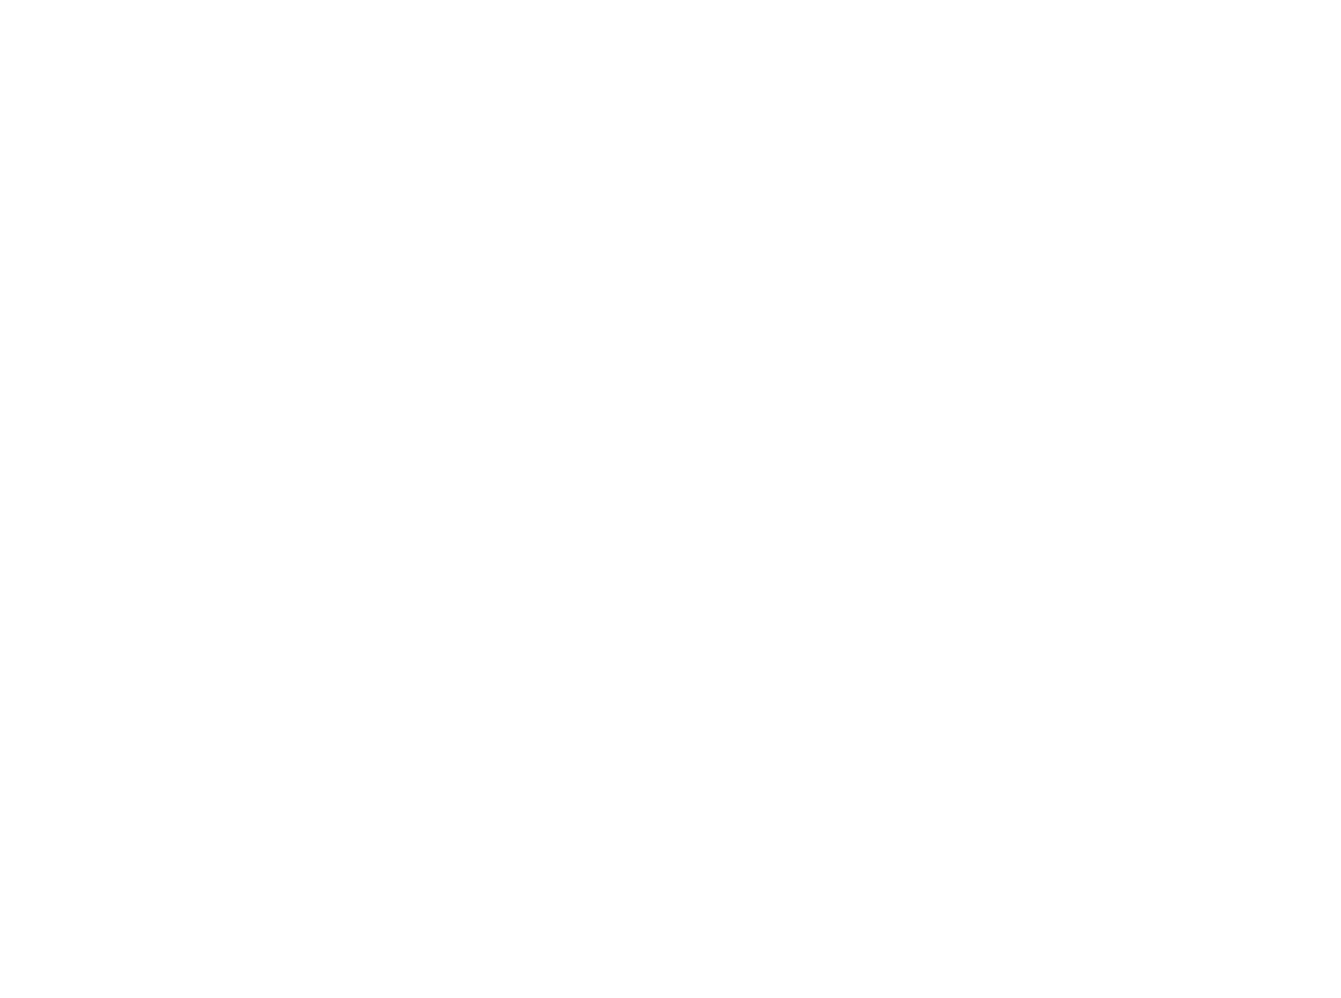
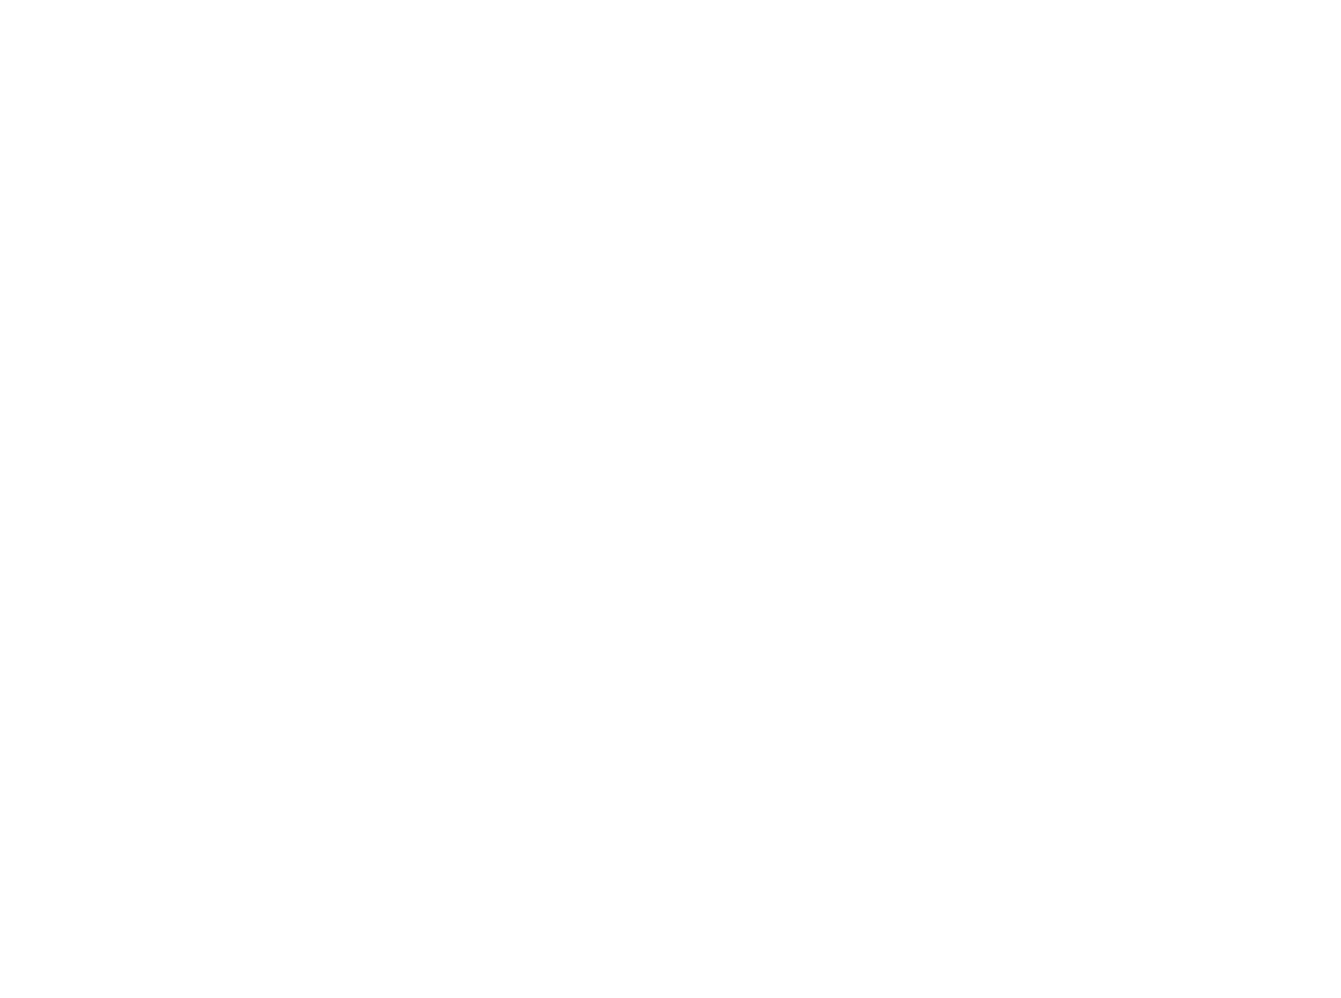
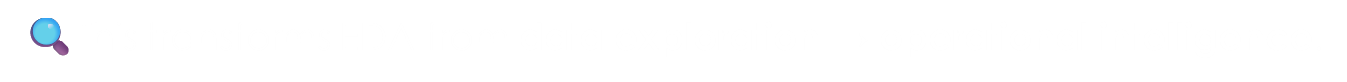
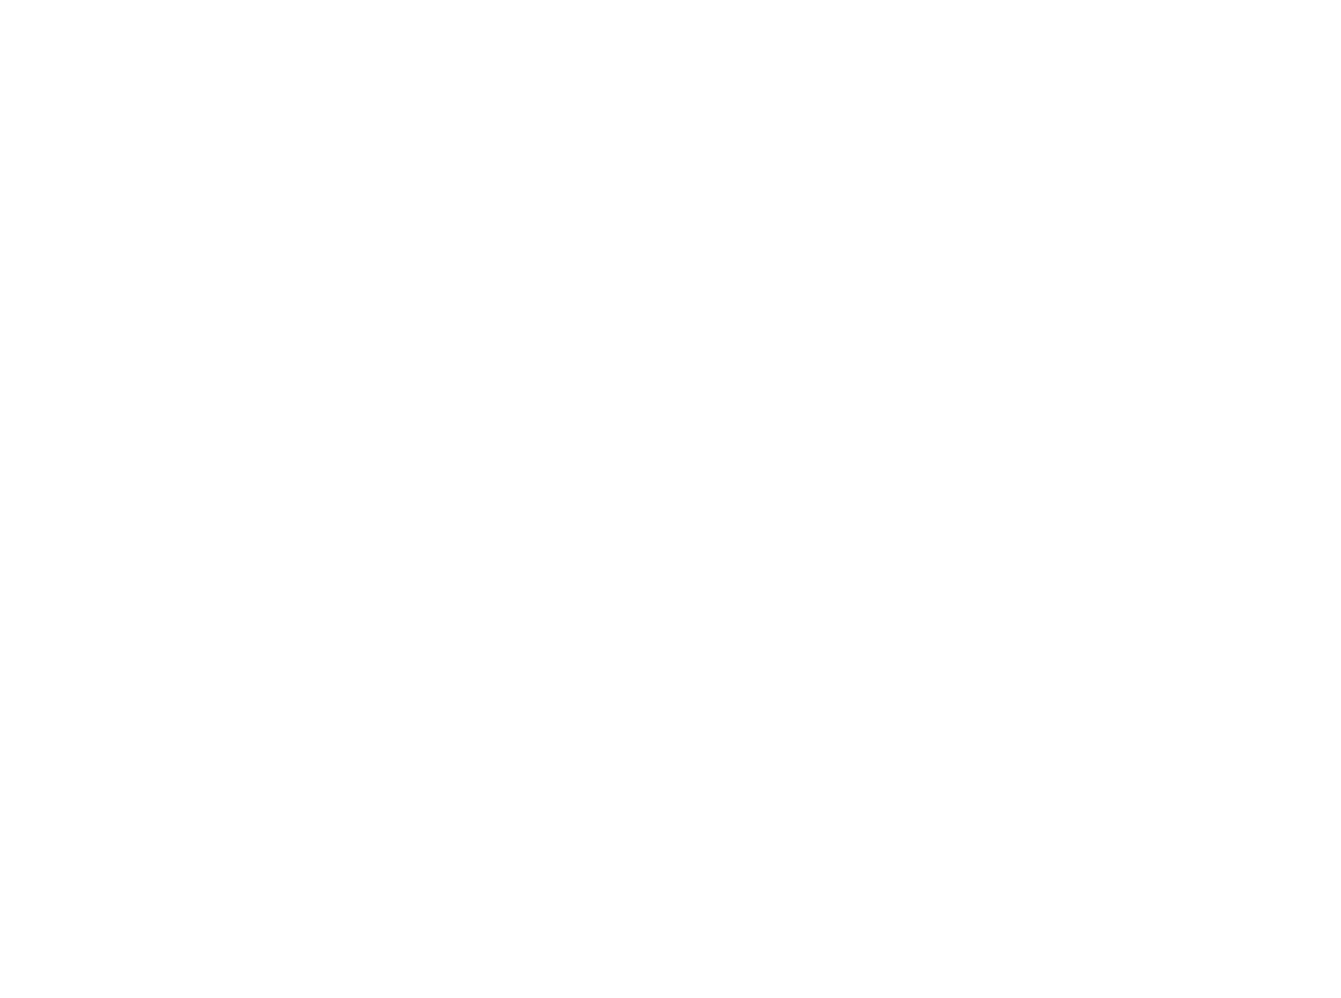